## Explorative Datenanalyse (eda.ipynb)
### Zelle 1: Imports & Einstellungen

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style-Einstellungen für ansprechende Plots
sns.set_theme(style="whitegrid")
%matplotlib inline

### Zelle 2: Daten laden & Erster Überblick

In [3]:
# Pfad anpassen an deinen Unterordner
DATA_PATH = "data/data_atlantico.csv"

df = pd.read_csv(DATA_PATH)

print(f"Datensatz-Form (Zeilen, Spalten): {df.shape}\n")
print("Die ersten 5 Zeilen:")
display(df.head())

print("\nDatentypen und Null-Werte:")
print(df.info())

Datensatz-Form (Zeilen, Spalten): (440, 6)

Die ersten 5 Zeilen:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185



Datentypen und Null-Werte:
<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Fresh             440 non-null    int64
 1   Milk              440 non-null    int64
 2   Grocery           440 non-null    int64
 3   Frozen            440 non-null    int64
 4   Detergents_Paper  440 non-null    int64
 5   Delicassen        440 non-null    int64
dtypes: int64(6)
memory usage: 20.8 KB
None


### Zelle 3: Statistische Kennzahlen & Schiefe (Skewness)

In [4]:
# Namen der Produktkategorien
spending_cols = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]

# Statistische Übersicht
print("--- Deskriptive Statistik ---")
display(df[spending_cols].describe().round(0))

# Schiefe der Verteilung prüfen (Werte > 1 deuten auf stark rechtsschiefe Daten hin)
print("\n--- Schiefe (Skewness) der Kategorien ---")
print(df[spending_cols].skew().round(2))

--- Deskriptive Statistik ---


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.0,440.0,440.0,440.0,440.0,440.0
mean,12000.0,5796.0,7951.0,3072.0,2881.0,1525.0
std,12647.0,7380.0,9503.0,4855.0,4768.0,2820.0
min,3.0,55.0,3.0,25.0,3.0,3.0
25%,3128.0,1533.0,2153.0,742.0,257.0,408.0
50%,8504.0,3627.0,4756.0,1526.0,816.0,966.0
75%,16934.0,7190.0,10656.0,3554.0,3922.0,1820.0
max,112151.0,73498.0,92780.0,60869.0,40827.0,47943.0



--- Schiefe (Skewness) der Kategorien ---
Fresh                2.56
Milk                 4.05
Grocery              3.59
Frozen               5.91
Detergents_Paper     3.63
Delicassen          11.15
dtype: float64


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Fresh             440 non-null    int64
 1   Milk              440 non-null    int64
 2   Grocery           440 non-null    int64
 3   Frozen            440 non-null    int64
 4   Detergents_Paper  440 non-null    int64
 5   Delicassen        440 non-null    int64
dtypes: int64(6)
memory usage: 20.8 KB


### Zelle 4: Visualisierung der Verteilungen (Histograms / KDE)

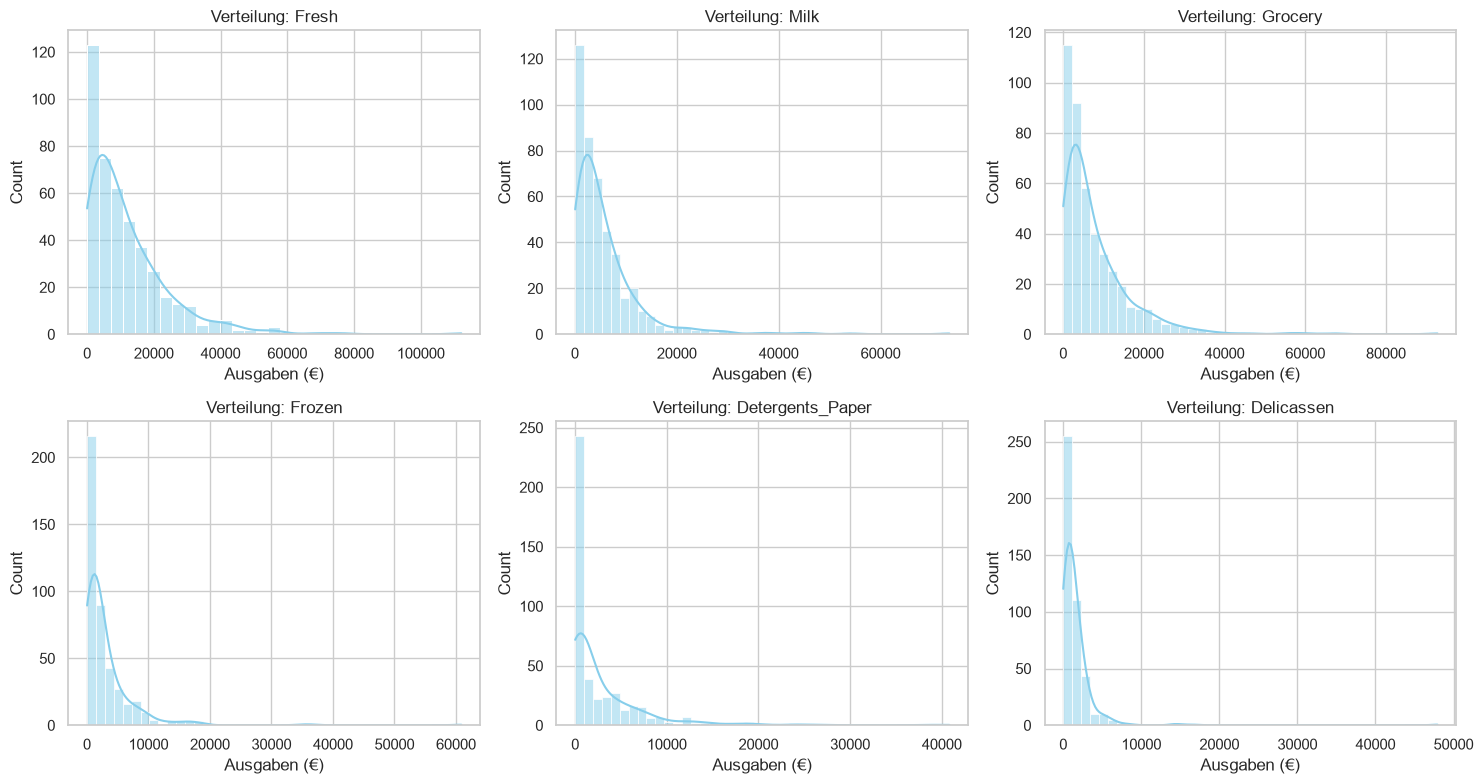

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(spending_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="skyblue")
    axes[i].set_title(f"Verteilung: {col}")
    axes[i].set_xlabel("Ausgaben (€)")

plt.tight_layout()
plt.show()

* Die Histogramme zu den Produktkategorien sind alle sehr rechtsschief, also unausgeglichen.
* Es gibt einige Wenige Käufe mit enormen Summen und eine große Anzahl von Käufen zwischen 0-20K€ bzw. 0-40k€

### Zelle 5: Korrelationsanalyse zwischen den Produktkategorien

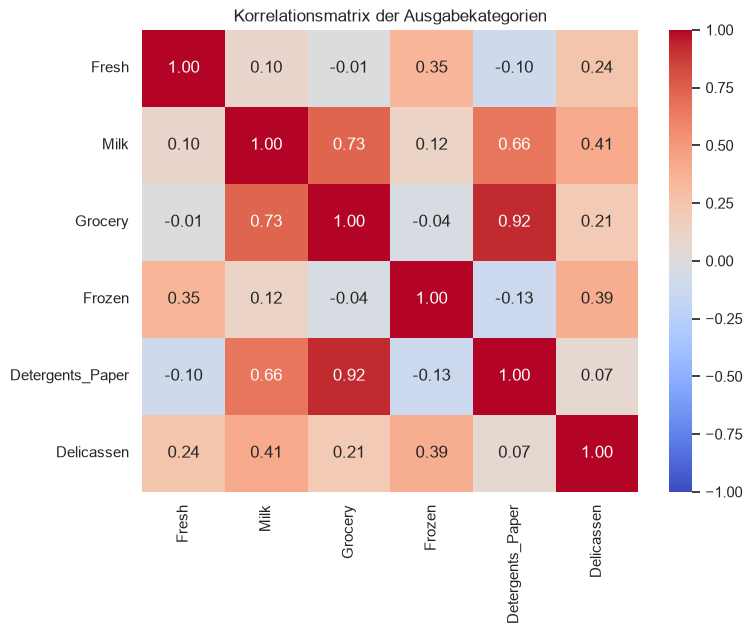

In [7]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[spending_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Korrelationsmatrix der Ausgabekategorien")
plt.show()

In [8]:
# Die Top 5 Kunden mit den höchsten Ausgaben in der Kategorie 'Fresh'
df.sort_values(by="Fresh", ascending=False)[["Fresh"] + spending_cols].head(5)

,Fresh,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
181,112151,112151,29627,18148,16745,4948,8550
125,76237,76237,3473,7102,16538,778,918
284,68951,68951,4411,12609,8692,751,2406
39,56159,56159,555,902,10002,212,2916
258,56083,56083,4563,2124,6422,730,3321


In [9]:
# Vergleich zwischen Median (50%), 90%-Quantil und Maximum für 'Fresh' und 'Grocery'
df[["Fresh", "Grocery"]].quantile([0.5, 0.75, 0.90, 0.95, 0.99, 1.0])

,Fresh,Grocery
0.50,8504.00,4755.50
0.75,16933.75,10655.75
0.90,27090.50,18910.10
0.95,36818.50,24033.50
0.99,56082.61,43435.74
1.00,112151.00,92780.00


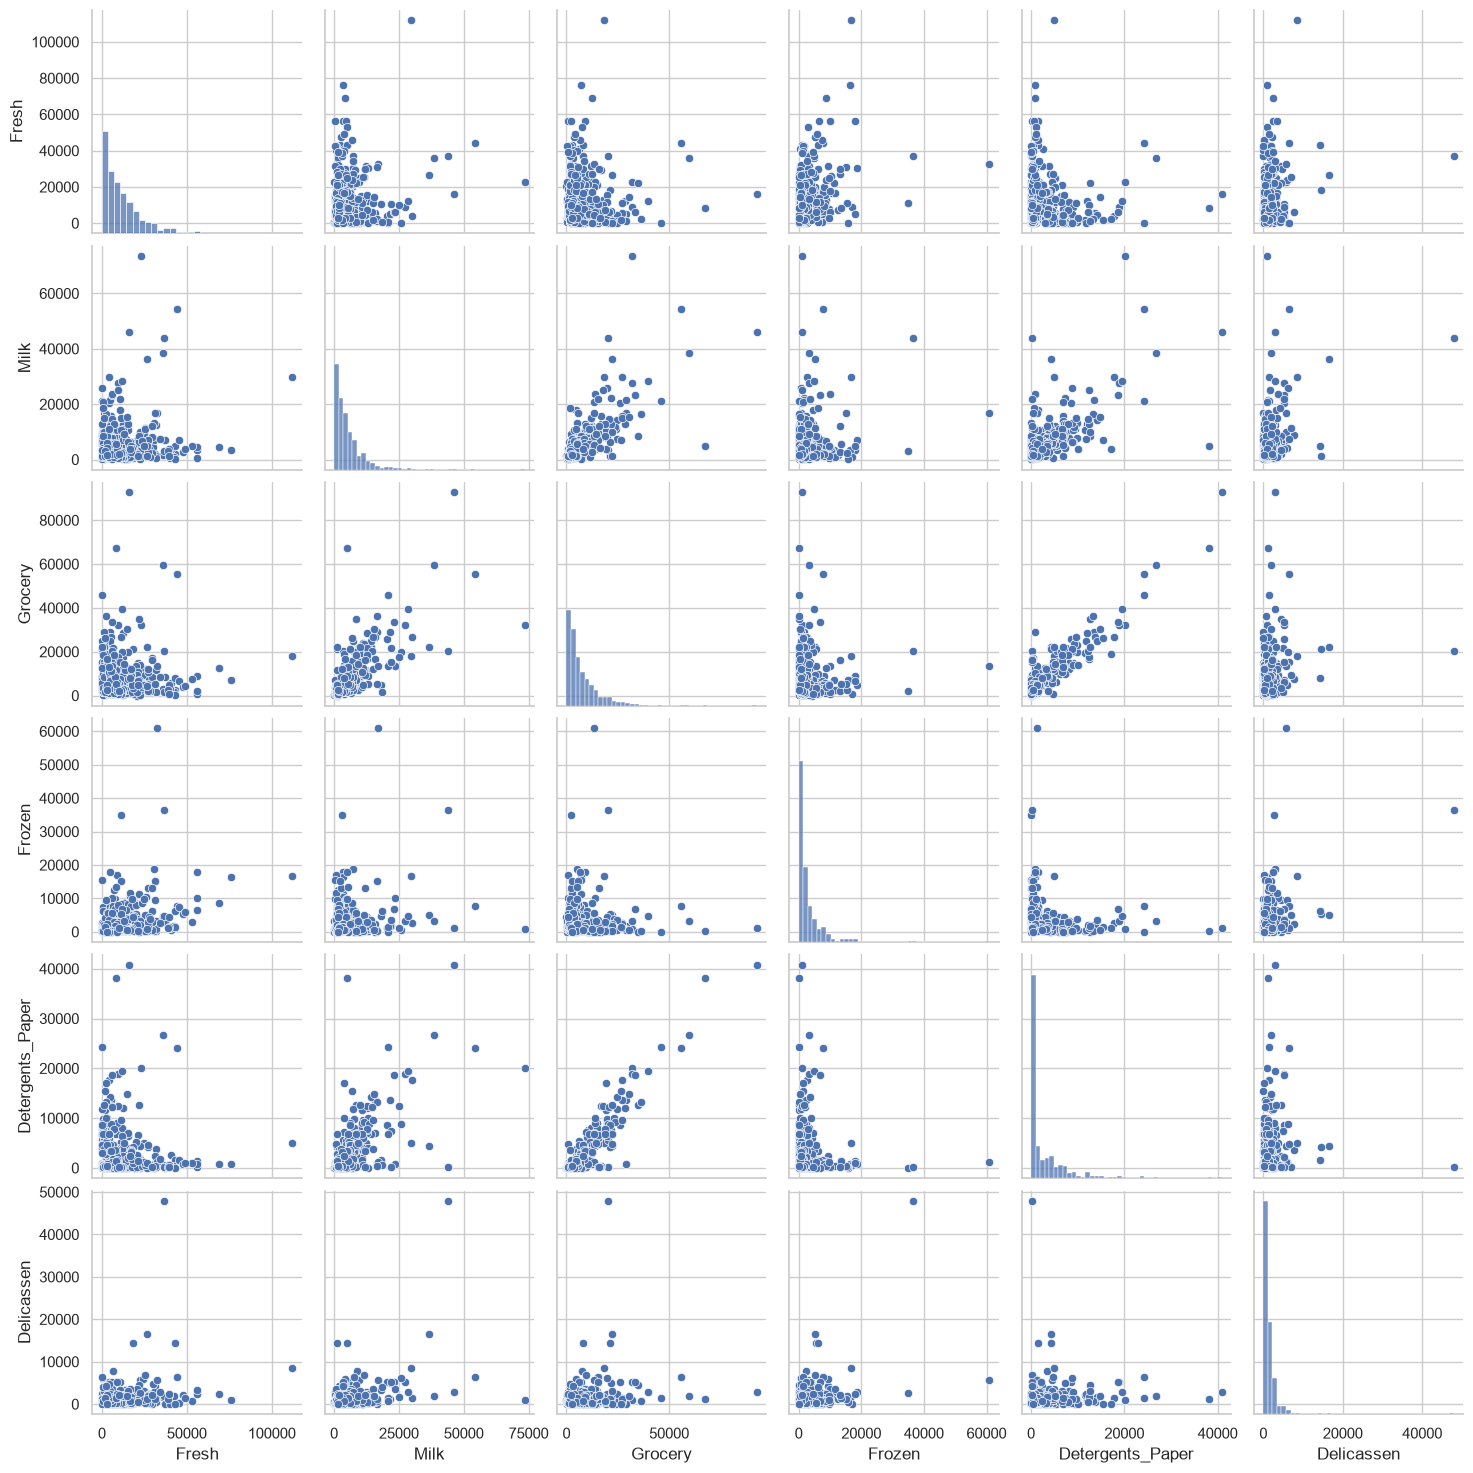

In [10]:
sns.pairplot(df[spending_cols])

### Erste deutliche Findings:
* Die Daten sind extrem rechtsschief, und vereinzelte Kundenpunkte liegen weit außerhalb der Hauptwolke.
#### Manuelle Schwellenwerte vs. Isolation Forest
* Überlegung, ob man diese Kunden herauswerfen sollte (Kernproblem beim Unsupervised ML)
* Warum das Entfernen für Clustering & PCA sinnvoll ist: 
1. Verzerrung der Clusterzentren (K-Means): K-Means basiert auf euklidischen Distanzen (Quadratfehlsummen). Extreme Ausreißer „ziehen“ ganze Clusterzentren an sich oder bilden ein eigenes Cluster mit nur 1–2 Kunden.
2. Dominanz bei der PCA: Die Hauptkomponentenanalyse sucht nach den Richtungen maximaler Varianz. Ein Einzelkunde mit $110.000\,\text{€}$ bei Fresh zieht die erste PCA-Achse fast alleine auf sich, wodurch die feineren Unterschiede der übrigen 95 % der Kunden untergehen.

### EDA: Kunden filtern & vergleichen

In [11]:
# 1. Definieren deiner Schwellenwerte
custom_thresholds = {
    "Fresh": 60000,
    "Milk": 40000,
    "Grocery": 40000,
    "Frozen": 20000,
    "Detergents_Paper": 20000,
    "Delicassen": 10000
}

# 2. Erstellen einer Maske für Ausreißer basierend auf den Grenzwerten
outliers_mask = pd.Series(False, index=df.index)

for col, limit in custom_thresholds.items():
    col_outliers = df[col] >= limit
    outliers_mask |= col_outliers
    print(f"Kunden mit {col} >= {limit}€: {col_outliers.sum()}")

print("-" * 50)
print(f"Gesamtzahl gefilterter Ausreißer-Kunden (manuell): {outliers_mask.sum()} von {len(df)}")

# 3. Datensatz aufteilen
df_manual_clean = df[~outliers_mask].copy()
df_manual_outliers = df[outliers_mask].copy()

# 4. Gegenüberstellung der Mittelwerte und Maxima
comparison = pd.DataFrame({
    "Original Mean": df[spending_cols].mean(),
    "Clean Mean": df_manual_clean.mean()[spending_cols],
    "Original Max": df[spending_cols].max(),
    "Clean Max": df_manual_clean.max()[spending_cols]
}).round(0)

display(comparison)

Kunden mit Fresh >= 60000€: 3
Kunden mit Milk >= 40000€: 4
Kunden mit Grocery >= 40000€: 5
Kunden mit Frozen >= 20000€: 3
Kunden mit Detergents_Paper >= 20000€: 6
Kunden mit Delicassen >= 10000€: 4
--------------------------------------------------
Gesamtzahl gefilterter Ausreißer-Kunden (manuell): 15 von 440


,Original Mean,Clean Mean,Original Max,Clean Max
Fresh,12000.0,11120.0,112151,56159
Milk,5796.0,5101.0,73498,29892
Grocery,7951.0,7107.0,92780,39694
Frozen,3072.0,2699.0,60869,18711
Detergents_Paper,2881.0,2531.0,40827,19410
Delicassen,1525.0,1276.0,47943,7844


bei 3-6 Ausreißern je Produktkategorie wäre es doch spannend wie viele Kunden das tatsächlich betrifft. 

In [12]:
# 1. Schwellenwerte definieren
custom_thresholds = {
    "Fresh": 60000,
    "Milk": 40000,
    "Grocery": 40000,
    "Frozen": 20000,
    "Detergents_Paper": 20000,
    "Delicassen": 10000
}

# 2. Prüfen, welche Spalte(n) bei welchem Kunden den Grenzwert überschreiten
outlier_details = pd.DataFrame(index=df.index)

for col, limit in custom_thresholds.items():
    outlier_details[f"{col}_exceeded"] = df[col] >= limit

# Filter: Nur Kunden, die mindestens einen Grenzwert überschreiten
has_any_outlier = outlier_details.any(axis=1)
outlier_indices = df[has_any_outlier].index

print(f"Es gibt insgesamt {len(outlier_indices)} EINZELNE Kunden, die mindestens einen Grenzwert überschreiten.\n")

# 3. Explizite Tabelle der betroffenen Kundenzeilen anzeigen
outlier_customers = df.loc[outlier_indices, spending_cols].copy()

# Hinzufügen einer Spalte, die zeigt, WELCHE Kategorien überschritten wurden
outlier_customers["Überschrittene_Kategorien"] = outlier_details.loc[outlier_indices].apply(
    lambda row: [col.replace("_exceeded", "") for col in row.index if row[col]], axis=1
)

# Sortiert nach der Gesamtausgabe
outlier_customers["Gesamtausgabe"] = outlier_customers[spending_cols].sum(axis=1)
outlier_customers = outlier_customers.sort_values(by="Gesamtausgabe", ascending=False)

display(outlier_customers)

Es gibt insgesamt 15 EINZELNE Kunden, die mindestens einen Grenzwert überschreiten.



,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Überschrittene_Kategorien,Gesamtausgabe
85,16117,46197,92780,1026,40827,2944,"[Milk, Grocery, Detergents_Paper]",199891
47,44466,54259,55571,7782,24171,6465,"[Milk, Grocery, Detergents_Paper]",192714
181,112151,29627,18148,16745,4948,8550,[Fresh],190169
183,36847,43950,20170,36534,239,47943,"[Milk, Frozen, Delicassen]",185683
61,35942,38369,59598,3254,26701,2017,"[Grocery, Detergents_Paper]",165881
86,22925,73498,32114,987,20070,903,"[Milk, Detergents_Paper]",150497
325,32717,16784,13626,60869,1272,5609,[Frozen],130877
333,8565,4980,67298,131,38102,1215,"[Grocery, Detergents_Paper]",120291
23,26373,36423,22019,5154,4337,16523,[Delicassen],110829
125,76237,3473,7102,16538,778,918,[Fresh],105046


### Absolute und prozentuale Null-Werte je Spalte prüfen

In [13]:
# Absolute Anzahl der Null-Werte pro Spalte
missing_values = df.isna().sum()

# Prozentualer Anteil der Null-Werte pro Spalte
missing_percent = (df.isna().sum() / len(df)) * 100

# Übersicht als DataFrame zusammenfassen
missing_df = pd.DataFrame({
    'Fehlende Werte (Absolut)': missing_values,
    'Fehlende Werte (%)': missing_percent.round(2)
})

print("--- Übersicht fehlender Werte ---")
display(missing_df)

--- Übersicht fehlender Werte ---


,Fehlende Werte (Absolut),Fehlende Werte (%)
Fresh,0,0.0
Milk,0,0.0
Grocery,0,0.0
Frozen,0,0.0
Detergents_Paper,0,0.0
Delicassen,0,0.0


* keine NULL-Zellen im Datensatz

In [14]:
total_missing = df.isna().sum().sum()
print(f"Gesamtzahl aller fehlenden Zellen im Datensatz: {total_missing}")

Gesamtzahl aller fehlenden Zellen im Datensatz: 0


* Zur Sicherheit prüfen wir auch noch einmal ob Kunden 0€ in einer Produktkategorie ausgegeben haben

In [15]:
# Prüfen, wie viele Kunden 0 € in den Kategorien ausgeben !!
(df[spending_cols] == 0).sum()

Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

#### Das "Ausreißer-Dilemma" auf den Punkt gebrachtDie Verwirrung ist absolut verständlich. 
* Der Kernunterschied liegt zwischen „Sollen wir Ausreißer überhaupt entfernen?“ und 
* „Mit welcher Methode finden wir sie am saubersten?“:  Ausreißer entfernen? => Ja!
* Ausreißer müssen raus, weil K-Means und PCA sonst verzerrt werden.  
* Wie finden wir sie? => Automatisiert (Isolation Forest) statt manuell.
* Manuelle Grenzwerte (z. B. Fresh > 60k): Sie sind zwar intuitiv, aber subjektiv („Warum 60k und nicht 55k?“). 
* Außerdem übersehen sie Kunden, die in keiner Spalte extrem hoch liegen, aber in der Kombination aller Spalten ein ungewöhnliches Muster haben (z. B. $0€ bei Grocery, aber $30.000€ bei Delicassen).
#### Isolation Forest: Das ist ein unüberwachter Algorithmus, der sich alle 6 Dimensionen gleichzeitig anschaut und genau diese ungewöhnlichen Kombinationen ohne starre Bauchgefühl-Grenzen findet. 
* Fazit: Wir entfernen die Ausreißer auf jeden Fall! Wir nutzen in eda.ipynb manuellen Schwellenwerte, um die Daten zu verstehen, überlassen das finale Aussortieren für modeling.ipynb aber dem IsolationForest.